# Project 2: *Malware Classification for Santa*
> Santa's gift delivery systems have been infected with malware, and manually checking every system would cause serious delays. To solve this, we build an automatic malware classifier that takes images of the code running on Santa's systems and classifies each one as either safe or one of nine types of malware. In this project we compare several types of classifiers, select the best one through model selection and hyperparameter tuning, and investigate whether an ensemble of the best models can improve performance.


In this notebook we will:
| Section | Description |
|---|---|
| 0 | Set up imports, constants and load the dataset |
| 1 | Explore the dataset: class distribution, example images and pixel statistics |
| 2 | Split the data into training and test sets, and choose pre-processing and performance metric |
| 3 | **Problem 1:** Perform model selection with hyperparameter tuning on three different types of classifiers |
| 4 | **Problem 2:** Build an ensemble of the best models using majority voting and compare it to the best single model |
| 5 | Train the final model and estimate its performance on unseen data using the test set |
| 6 | Summarize the results |

## 0. Setup —

### 0.1 - Imports

In [45]:
#Data handling
import numpy as np
import pandas as pd

#Visualisation
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

#Data splitting
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Ensemble
from sklearn.ensemble import VotingClassifier

#Evaluation
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

### 0.2 - Constants and random seed
A fixed random seed is used everywhere so that all results can be reproduced.

In [46]:
SEED = 67 #Random seed
DATA_PATH = "data/dataset.npz"

#Class names from table 1 in the assignment. The index matches the labels (0-9)
CLASS_NAMES = ["Good", "Adware", "Trojan 1", "Trojan 2", "Installer", "Backdoor 1", "Crypto", "Backdoor 2", "Downloader", "Heuristic" ] 

### 0.3 - Load data

In [47]:
#Loading the dataset
dataset = np.load(DATA_PATH)
X, y = dataset["X"], dataset["y"]

#Overview
print("Number of images:", X.shape[0])
print("Pixels per image:", X.shape[1])
print(f"Pixel range: {int(X.min())} - {int(X.max())}")
print("Classes:", np.unique(y))

#Sanity check: compare with the description from the assignment
assert X.shape[1] == 1024, "Each image should have 1024 pixels (32x32)"
assert X.shape[0] == y.shape[0], "X and y should have the same amount of samples"
assert X.min() >= 0 and X.max() <= 255, "Pixel values should have range: 0 - 255"
assert set(np.unique(y)) == set(range(10)), "Labels should be 0-9"

print("\nAll sanity checks passed. We're good to go! :D")

Number of images: 15563
Pixels per image: 1024
Pixel range: 0 - 255
Classes: [0 1 2 3 4 5 6 7 8 9]

All sanity checks passed. We're good to go! :D


## 1. Data Exploration —
Before choosing the models, we look at the data to understand its structure and whether it affects our design choices.

### 1.1 - Class distribution

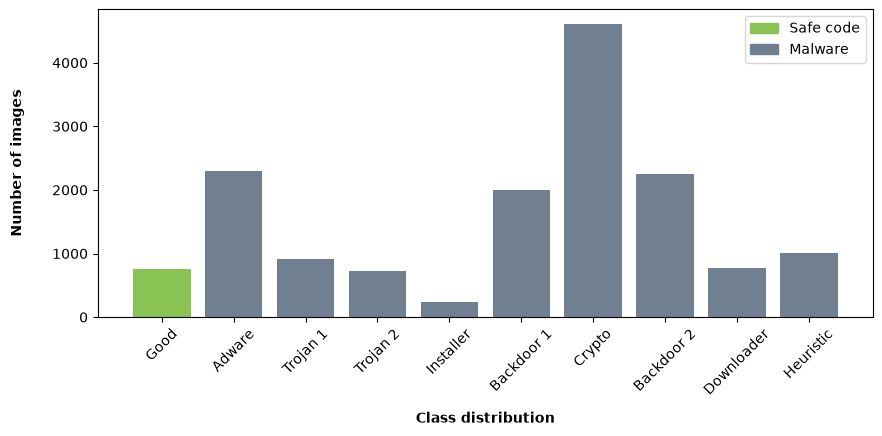

In [ ]:
counts = np.bincount(y) #number of images per class
colors = ["#88c354" if name == "Good" else "slategray" for name in CLASS_NAMES] 

plt.figure(figsize = (10,4))
plt.bar(CLASS_NAMES, counts, color = colors) #bar chart for each class
plt.xticks(rotation = 45)
plt.ylabel("Number of images", fontweight="bold",  labelpad=20)
plt.xlabel("Class distribution", fontweight="bold",  labelpad=10)
plt.legend(handles = [Patch(color = "#88c354", label = "Safe code"), Patch(color = "slategray", label = "Malware")])
plt.show()

### 1.2 - Example images per class

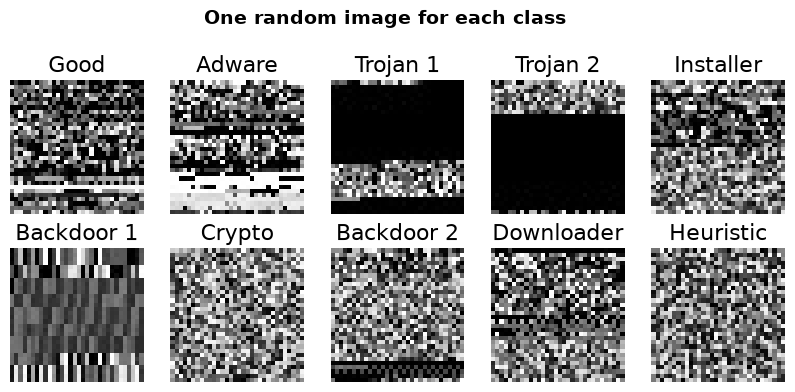

In [92]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 5, figsize = (10,4))

for this_class, ax in enumerate(axes.flat):
    k = rng.choice(np.where(y == this_class)[0]) #gets a random image from a spesific class
    ax.imshow(X[k].reshape(32,32), vmin=0, vmax=255, cmap="gray") #code taken from assignment
    ax.set_title(CLASS_NAMES[this_class], fontsize=16)
    ax.axis("off")

fig.suptitle("One random image for each class", fontweight="bold", fontsize=14, y=1.05)
plt.show()

### 1.3 - Avarage image per class

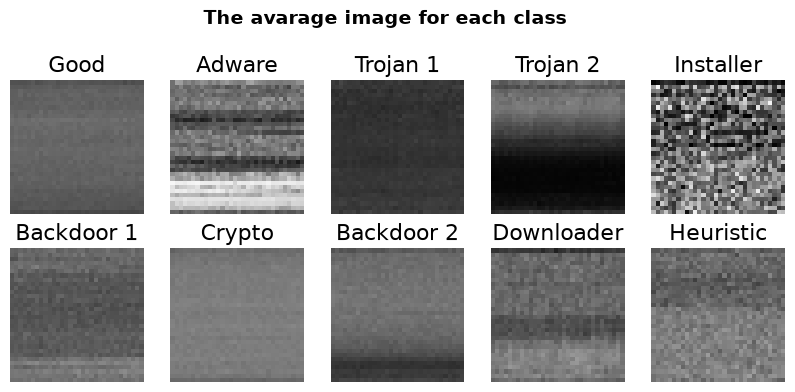

In [91]:
#A plot of all the avarage images for each class
fig, axes = plt.subplots(2, 5, figsize = (10,4))

mean_images = [X[y == this_class].mean(axis = 0) for this_class in range(10)] #the mean of each pixel for every image in a spesific class

for this_class, ax in enumerate(axes.flat):
    ax.imshow(mean_images[this_class].reshape(32,32), vmin=0, vmax=255, cmap="gray") #code taken from assignment
    ax.set_title(CLASS_NAMES[this_class], fontsize=16)
    ax.axis("off")

fig.suptitle("The avarage image for each class", fontweight="bold", fontsize=14, y=1.05)
plt.show()

### 1.4 - Similarity between classes

The 5 most similar classes in pairs (by average image):
Good         -     Backdoor 2     distance: 527.1
Good         -     Backdoor 1     distance: 656.9
Crypto       -     Heuristic      distance: 657.6
Backdoor 1   -     Downloader     distance: 694.0
Good         -     Downloader     distance: 780.7


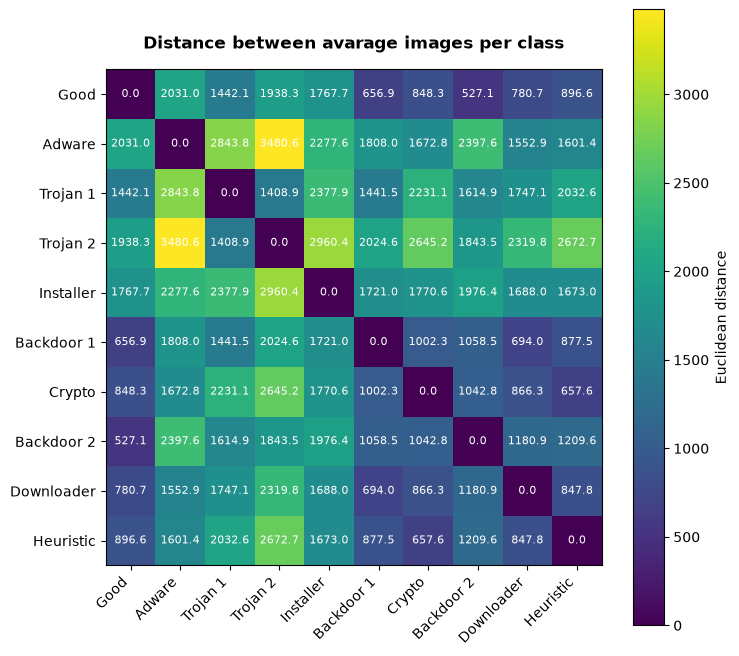

In [86]:
#Euclidean distance between every pair 
distances = np.zeros((10,10))

for i in range(10):
    for j in range(10):
        distances[i,j] = np.sqrt(np.sum((mean_images[i] - mean_images[j]) **2))

similar_pairs = [] #pairs that are most similar
for i in range(10):
    for j in range(i + 1, 10):
        similar_pairs.append((distances[i,j], CLASS_NAMES[i], CLASS_NAMES[j]))

similar_pairs.sort() #smallest distance first (smaller distance = more similar)

print("The 5 most similar classes in pairs (by average image):")
for dist, name_i, name_j in similar_pairs[:5]:
    print(f"{name_i:12} -     {name_j:12}   distance: {round(dist,1)}")


#Heatmap of similar classes
fig, ax = plt.subplots(figsize=(8,8))

image = ax.imshow(distances, cmap = "viridis")

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation = 45, ha ="right")
ax.set_yticklabels(CLASS_NAMES)

for i in range(10):
    for j in range(10):
        ax.text(j,i, f"{round(distances[i,j], 1)}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, label = "Euclidean distance")
ax.set_title("Distance between avarage images per class", fontweight="bold", pad = 15)
plt.show()

#### *Observation and hypothesis:*
The heatmap shows the Euclidean distance between the average images of each class. A small distance means that the classes look similar on average. Based on this, we hypothesise that the most similar class pairs will be harder for the models to tell apart. We will test this hypothesis by comparing these pairs with the confusion matrix of the final model in Section 5.3.

## 2. Preparation —

### 2.1 - Train/test split
forklar hvilken split vi gjør og hvorfor

In [ ]:
# code
#test set is not used until section 5

### 2.2 - Pre-processing

forklar hvordan vi prosseserer
eks:
> Pixel values are scaled to [range]. Scaling is placed inside a Pipeline so
that it is fitted only on the training folds, avoiding data leakage.

In [ ]:
#(e.g. scaling, inside a Pipeline)

### 2.3 - Choice of performance metric
valg av metric og hvorfro :eks:
> We use [metric] because [reason, e.g. it weighs all classes equally].

In [ ]:
# code

## 3. Problem 1 — Model Selection

### 3.1 - Model selection setup

In [ ]:
# code
#  (e.g. cross-validation on training data)

### 3.2 - Model A: name
eks:
> [Model] was chosen because [reason]. We tune [hyperparameters], since they
control [what, e.g. model complexity].

In [ ]:
# code + hyperparameter tuning

#hver modell tunes med cross-validation, 
# og vi printer beste hyperparametre og CV-score + kort kommentar

### 3.3 - Model B: name
eks: 
> [Model] was chosen because [reason]. We tune [hyperparameters], since they
control [what, e.g. model complexity].

In [ ]:
# code + hyperparameter tuning

#hver modell tunes med cross-validation, 
# og vi printer beste hyperparametre og CV-score + kort kommentar

### 3.4 - Model C: name
eks:
> [Model] was chosen because [reason]. We tune [hyperparameters], since they
control [what, e.g. model complexity].

In [ ]:
# code + hyperparameter tuning

#hver modell tunes med cross-validation, 
# og vi printer beste hyperparametre og CV-score + kort kommentar

### 3.5 - Comparison and automatic selection of the best model
eks:
> The model with the highest mean CV [metric] is selected automatically.

In [ ]:
# code
# tabell som sammenligner de tre modellene
# skriv kommentar av valget: [Model] performs best, likely because [reason]

# legg til noe som viser: runtime (everything should run in < 30 min)

## 4. Problem 2 — Ensemble

### 4.1 - Build ensemble with majority voting
eks:
> The ensemble combines the best model of each type using [hard/soft]
majority voting.

In [ ]:
#code

### 4.2 - Evaluate the ensemble

In [ ]:
#code 
# same as in problem1

# CV score for esemble

### 4.3 Ensemble vs. best single model

In [ ]:
# code
# skriv kommentar : why better or why worse?

#tabell eller søylediagram som sammenligner 

## 5. Final Model and Test Set Evaluation —


### 5.1 - Train final model on full training set

In [ ]:
#code

### 5.2 - Test set performance

In [ ]:
#code
#score på testsettet

### 5.3 - Confusion matrix and classification report

In [ ]:
#code
#confusion matrise plott og (classification report) <- vet ikke helt hva dette er

### 5.4 - Misclassified images

In [ ]:
#code
#rutenett med feilklassifiserte bilder

#kort kommentar på hvorfor disse bildene kan vøre vanskelig for modellen

## 6. Results —
Evt. en tabell med alt vi allerede har regnet ut